
     TUNING XGBOOST...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best XGB Params: {'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 7, 'learning_rate': 0.2, 'gamma': 0.1, 'colsample_bytree': 1.0}

     TUNING RANDOM FOREST...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best RF Params: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}

     TUNING LIGHTGBM...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003957 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 667
[LightGBM] [Info] Number of data points in the train set: 26604, number of used features: 34
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.

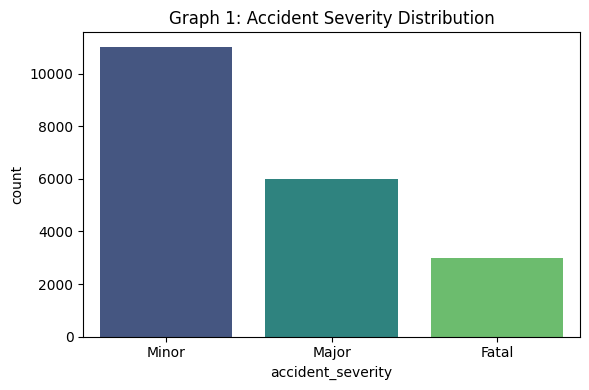

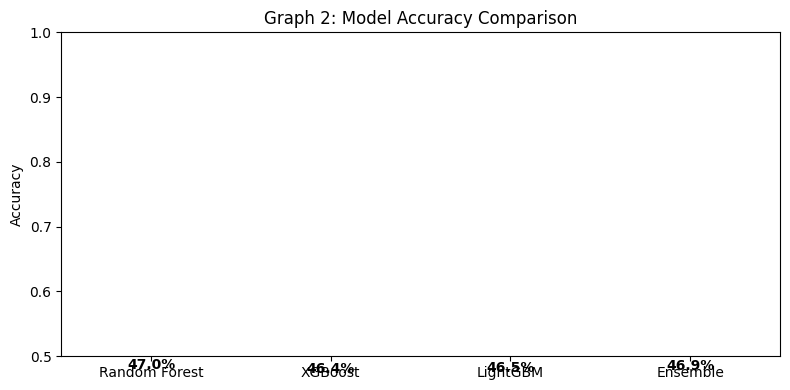

<Figure size 600x500 with 0 Axes>

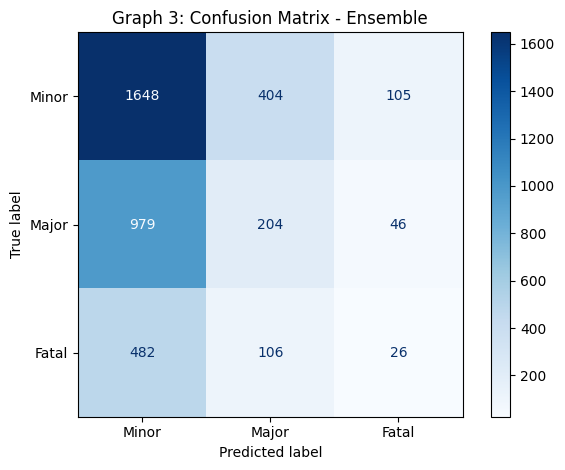

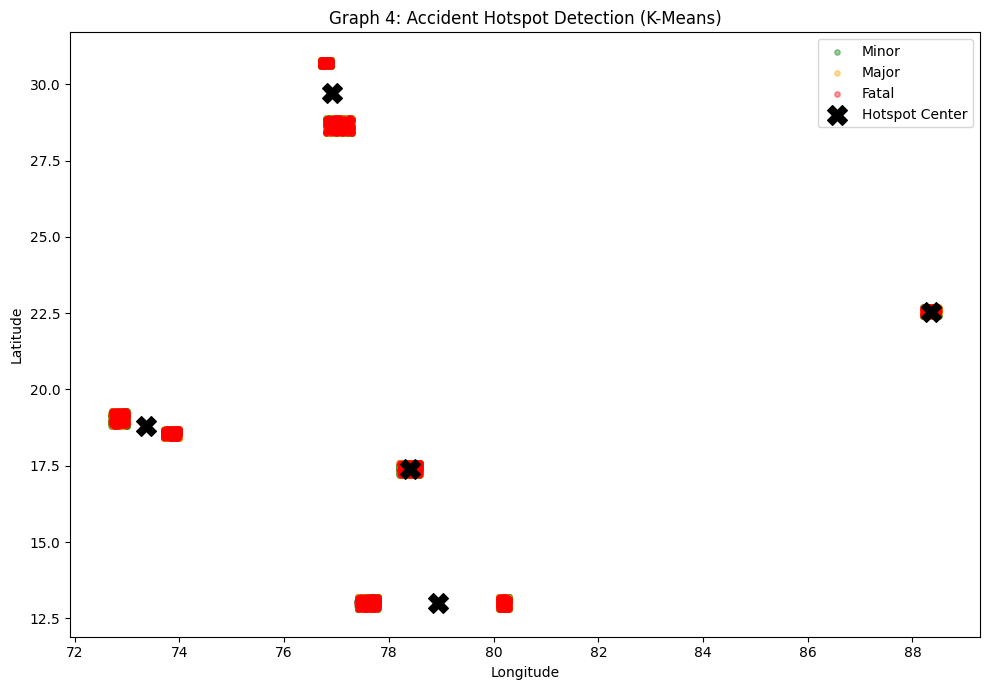


      ACCIDENT SEVERITY PREDICTOR

            PREDICTION RESULT
  Severity : MINOR 
  Minor    : 55.47%
  Major    : 34.07%
  Fatal    : 10.46%


In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.cluster import KMeans
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("indian_roads_dataset.csv")
df_orig = df.copy()

df = df.drop(["accident_id", "date", "time", "risk_score",
              "casualties", "vehicles_involved"], axis=1)
df["festival"] = df["festival"].fillna("None")
df = df.ffill()

df["high_risk"]   = ((df["visibility"] == "low") & (df["traffic_density"] == "high")).astype(int)
df["night_drive"] = df["hour"].apply(lambda x: 1 if x < 6 or x > 21 else 0)
df["peak_fog"]    = ((df["weather"] == "fog") & (df["is_peak_hour"] == 1)).astype(int)

ordinal_map = {
    "visibility"     : {"low": 0, "medium": 1, "high": 2},
    "traffic_density": {"low": 0, "medium": 1, "high": 2},
}
for col, mapping in ordinal_map.items():
    df[col] = df[col].map(mapping)

label_cols = ["city", "cause"]
encoders   = {}
for col in label_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

dummy_cols = ["state", "road_type", "weather", "festival", "day_of_week"]
df = pd.get_dummies(df, columns=dummy_cols, drop_first=True)

df["accident_severity"] = df["accident_severity"].map({"minor": 0, "major": 1, "fatal": 2})

X = df.drop("accident_severity", axis=1)
y = df["accident_severity"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

sm = SMOTE(random_state=10)
X_train, y_train = sm.fit_resample(X_train, y_train)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=10)

print("\n" + "="*45)
print("     TUNING XGBOOST...")
print("="*45)

xgb_params = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [3, 5, 7],
    'learning_rate'   : [0.05, 0.1, 0.2],
    'subsample'       : [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'min_child_weight': [1, 3],
    'gamma'           : [0, 0.1],
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(eval_metric='mlogloss', random_state=10),
    xgb_params,
    n_iter   = 20,
    cv       = skf,
    scoring  = 'f1_weighted',
    n_jobs   = -1,
    random_state = 10,
    verbose  = 1
)
xgb_search.fit(X_train, y_train)
best_xgb = xgb_search.best_estimator_
print("Best XGB Params:", xgb_search.best_params_)

print("\n" + "="*45)
print("     TUNING RANDOM FOREST...")
print("="*45)

rf_params = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf' : [1, 2],
    'max_features'     : ['sqrt', 'log2'],
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=10),
    rf_params,
    n_iter   = 20,
    cv       = skf,
    scoring  = 'f1_weighted',
    n_jobs   = -1,
    random_state = 10,
    verbose  = 1
)
rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_
print("Best RF Params:", rf_search.best_params_)

print("\n" + "="*45)
print("     TUNING LIGHTGBM...")
print("="*45)

lgbm_params = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [5, 7, 10],
    'learning_rate'   : [0.05, 0.1, 0.2],
    'num_leaves'      : [31, 50, 70],
    'subsample'       : [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}

lgbm_search = RandomizedSearchCV(
    LGBMClassifier(random_state=10),
    lgbm_params,
    n_iter   = 20,
    cv       = skf,
    scoring  = 'f1_weighted',
    n_jobs   = -1,
    random_state = 10,
    verbose  = 1
)
lgbm_search.fit(X_train, y_train)
best_lgbm = lgbm_search.best_estimator_
print("Best LGBM Params:", lgbm_search.best_params_)

skf5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=10)
rf_cv   = cross_val_score(best_rf,   X_train, y_train, cv=skf5, scoring='accuracy', n_jobs=-1)
xgb_cv  = cross_val_score(best_xgb,  X_train, y_train, cv=skf5, scoring='accuracy', n_jobs=-1)
lgbm_cv = cross_val_score(best_lgbm, X_train, y_train, cv=skf5, scoring='accuracy', n_jobs=-1)

print("\n" + "="*50)
print("       5-FOLD CROSS VALIDATION RESULTS")
print("="*50)
print(f"  Random Forest  Mean: {rf_cv.mean()*100:.2f}%  Std: {rf_cv.std()*100:.2f}%")
print(f"  XGBoost        Mean: {xgb_cv.mean()*100:.2f}%  Std: {xgb_cv.std()*100:.2f}%")
print(f"  LightGBM       Mean: {lgbm_cv.mean()*100:.2f}%  Std: {lgbm_cv.std()*100:.2f}%")
print("="*50)

voting_clf = VotingClassifier(
    estimators=[('rf', best_rf), ('xgb', best_xgb), ('lgbm', best_lgbm)],
    voting='soft', weights=[1, 2, 2]
)
voting_clf.fit(X_train, y_train)
y_pred       = voting_clf.predict(X_test)

rf_acc       = accuracy_score(y_test, best_rf.predict(X_test))
xgb_acc      = accuracy_score(y_test, best_xgb.predict(X_test))
lgbm_acc     = accuracy_score(y_test, best_lgbm.predict(X_test))
ensemble_acc = accuracy_score(y_test, y_pred)

print("\n" + "="*50)
print("          MODEL ACCURACY REPORT")
print("="*50)
print(f"  Random Forest : {rf_acc*100:.2f}%  (CV: {rf_cv.mean()*100:.2f}%)")
print(f"  XGBoost       : {xgb_acc*100:.2f}%  (CV: {xgb_cv.mean()*100:.2f}%)")
print(f"  LightGBM      : {lgbm_acc*100:.2f}%  (CV: {lgbm_cv.mean()*100:.2f}%)")
print(f"  Ensemble      : {ensemble_acc*100:.2f}%")
print("="*50)
print(f"  Best Accuracy : {max(rf_acc,xgb_acc,lgbm_acc,ensemble_acc)*100:.2f}%")
print("="*50)
print(classification_report(y_test, y_pred, target_names=["Minor","Major","Fatal"]))

plt.figure(figsize=(6,4))
sns.countplot(x=y, palette='viridis')
plt.title("Graph 1: Accident Severity Distribution")
plt.xticks([0,1,2], ['Minor', 'Major', 'Fatal'])
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4))
models     = ['Random Forest', 'XGBoost', 'LightGBM', 'Ensemble']
accuracies = [rf_acc, xgb_acc, lgbm_acc, ensemble_acc]
sns.barplot(x=models, y=accuracies, palette='rocket')
plt.title("Graph 2: Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0.5, 1.0)
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f"{v*100:.1f}%", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,5))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Minor','Major','Fatal']).plot(cmap='Blues')
plt.title("Graph 3: Confusion Matrix - Ensemble")
plt.tight_layout()
plt.show()

coords           = df_orig[["latitude", "longitude"]].dropna()
kmeans           = KMeans(n_clusters=5, random_state=10, n_init=10)
coords           = coords.copy()
coords["cluster"]  = kmeans.fit_predict(coords)
severity_num       = df_orig["accident_severity"].map({"minor": 0, "major": 1, "fatal": 2})
coords["severity"] = severity_num.values

colors_map = {0: 'green', 1: 'orange', 2: 'red'}
plt.figure(figsize=(10,7))
for sev, color in colors_map.items():
    mask  = coords["severity"] == sev
    label = ["Minor","Major","Fatal"][sev]
    plt.scatter(coords[mask]["longitude"], coords[mask]["latitude"],
                c=color, label=label, alpha=0.4, s=15)
centers = kmeans.cluster_centers_
plt.scatter(centers[:,1], centers[:,0], c='black', marker='X',
            s=200, zorder=5, label='Hotspot Center')
plt.title("Graph 4: Accident Hotspot Detection (K-Means)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("      ACCIDENT SEVERITY PREDICTOR")
print("="*50)

city            = input("City (Pune/Mumbai/Delhi etc)       : ").strip()
state           = input("State (Maharashtra/Delhi etc)      : ").strip()
hour            = int(input("Hour (0-23)                        : "))
day_of_week     = input("Day (Monday/Sunday etc)            : ").strip()
is_weekend      = int(input("Is Weekend? (1=Yes 0=No)           : "))
road_type       = input("Road Type (highway/urban/rural)    : ").strip()
lanes           = int(input("Lanes (1/2/3/4)                    : "))
traffic_signal  = int(input("Traffic Signal (1=Yes 0=No)        : "))
weather         = input("Weather (clear/fog/rain)           : ").strip()
visibility      = input("Visibility (low/medium/high)       : ").strip().lower()
temperature     = float(input("Temperature (15-40)                : "))
traffic_density = input("Traffic Density (low/medium/high)  : ").strip().lower()
cause           = input("Cause (speeding/weather/distraction/drunk driving/poor road): ").strip()
is_peak_hour    = int(input("Is Peak Hour? (1=Yes 0=No)         : "))
festival        = input("Festival (None/Diwali/Holi/Eid)    : ").strip()

vis_map     = {"low": 0, "medium": 1, "high": 2}
traffic_map = {"low": 0, "medium": 1, "high": 2}

city_enc  = encoders['city'].transform([city])[0]   if city  in encoders['city'].classes_  else 0
cause_enc = encoders['cause'].transform([cause])[0] if cause in encoders['cause'].classes_ else 0

user_input = {
    'city'           : city_enc,
    'hour'           : hour,
    'is_weekend'     : is_weekend,
    'lanes'          : lanes,
    'traffic_signal' : traffic_signal,
    'visibility'     : vis_map.get(visibility, 1),
    'temperature'    : temperature,
    'traffic_density': traffic_map.get(traffic_density, 1),
    'cause'          : cause_enc,
    'is_peak_hour'   : is_peak_hour,
    'high_risk'      : 1 if (visibility == "low" and traffic_density == "high") else 0,
    'night_drive'    : 1 if hour < 6 or hour > 21 else 0,
    'peak_fog'       : 1 if (weather == "fog" and is_peak_hour == 1) else 0,
}

user_df = pd.DataFrame([user_input])

for col in scaler.feature_names_in_:
    if col not in user_df.columns:
        user_df[col] = 0

for col in scaler.feature_names_in_:
    if f"state_{state}"             == col: user_df[col] = 1
    if f"road_type_{road_type}"     == col: user_df[col] = 1
    if f"weather_{weather}"         == col: user_df[col] = 1
    if f"festival_{festival}"       == col: user_df[col] = 1
    if f"day_of_week_{day_of_week}" == col: user_df[col] = 1

user_df     = user_df[scaler.feature_names_in_]
user_scaled = scaler.transform(user_df)

prediction = voting_clf.predict(user_scaled)[0]
prob       = voting_clf.predict_proba(user_scaled)[0]

severity_map = {0: "MINOR ", 1: "MAJOR ", 2: "FATAL "}

print("\n" + "="*50)
print("            PREDICTION RESULT")
print("="*50)
print(f"  Severity : {severity_map[prediction]}")
print(f"  Minor    : {prob[0]*100:.2f}%")
print(f"  Major    : {prob[1]*100:.2f}%")
print(f"  Fatal    : {prob[2]*100:.2f}%")
print("="*50)